# Devnagari Handwritten Digit Classification using FCN

task 2


In [1]:
from tensorflow import keras
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

model = Sequential([
    Dense(64, activation='sigmoid', input_shape=(784,)),
    Dense(128, activation='sigmoid'),
    Dense(256, activation='sigmoid'),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

task 3

In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=2)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

313/313 - 1s - 2ms/step - accuracy: 0.9664 - loss: 0.1096
Test Loss: 0.1096
Test Accuracy: 0.9664


task 4

In [11]:
model.save('devnagari_fcn_model.h5')
print("Model saved to devnagari_fcn_model.h5")

loaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')
print("Model loaded successfully")

loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test_cat, verbose=2)
print(f"Loaded Model - Test Loss: {loaded_loss:.4f}, Test Accuracy: {loaded_acc:.4f}")

Model saved to devnagari_fcn_model.h5
Model loaded successfully
313/313 - 1s - 3ms/step - accuracy: 0.9664 - loss: 0.1096
Loaded Model - Test Loss: 0.1096, Test Accuracy: 0.9664


task 5

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predicted label for first image: 7
True label for first image: 7


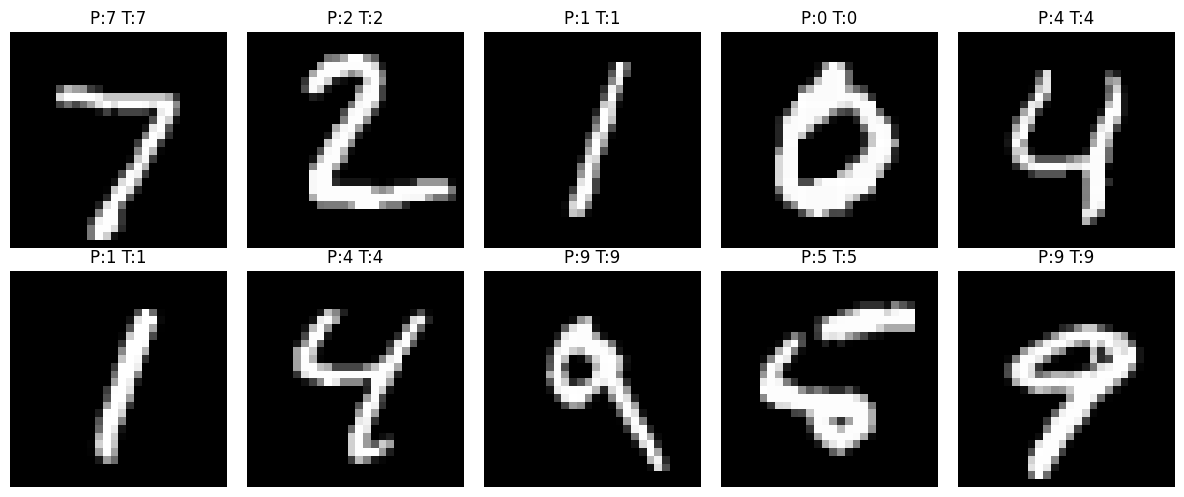

In [12]:
 predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {y_test[0]}")

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"P:{predicted_labels[i]} T:{y_test[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()